## Support Vector Machines

Vamos criar os mesmos dados fabricados de renda / idade agrupados que usamos no nosso exemplo de clustering com K-Means:

In [ ]:
import numpy as np

# funcao que cria dados falsos de renda/idade agrupados em k clusters, pra N pessoas
def createClusteredData(N, k):
    np.random.seed(1234)
    pointsPerCluster = float(N)/k
    X = []
    y = []
    for i in range (k):
        incomeCentroid = np.random.uniform(20000.0, 200000.0)
        ageCentroid = np.random.uniform(20.0, 70.0)
        for j in range(int(pointsPerCluster)):
            X.append([np.random.normal(incomeCentroid, 10000.0), np.random.normal(ageCentroid, 2.0)])
            y.append(i)
    X = np.array(X)
    y = np.array(y)
    return X, y

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

#gerando os dados falsos e plotando sem escala nenhuma ainda
(X, y) = createClusteredData(100, 5)

plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], c=y.astype(float))
plt.show()

#escalando os dados pra ficar entre -1 e 1, importante pro SVC convergir direito
scaling = MinMaxScaler(feature_range=(-1,1)).fit(X)
X = scaling.transform(X)

#plotando de novo com os dados ja escalados (o formato dos clusters nao muda, so a escala dos eixos)
plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], X[:,1], c=y.astype(float))
plt.show()

Agora vamos usar o SVC linear para dividir nosso gráfico em clusters:

In [ ]:
from sklearn import svm, datasets

C = 1.0
# treinando um SVC com kernel linear pra separar os clusters
svc = svm.SVC(kernel='linear', C=C).fit(X, y)

Ao montar uma malha densa de pontos na grade e classificar todos eles, podemos renderizar as regiões de cada cluster como cores distintas:

In [ ]:
def plotPredictions(clf):
    #criando uma malha densa de pontos pra cobrir todo o grafico
    xx, yy = np.meshgrid(np.arange(-1, 1, .001),
                         np.arange(-1, 1, .001))
    
    #transformando a malha em arrays do numpy
    npx = xx.ravel()
    npy = yy.ravel()
    
    #convertendo pra uma lista de pontos 2D (renda, idade)
    samplePoints = np.c_[npx, npy]
    
    #prevendo o cluster de cada ponto da malha
    Z = clf.predict(samplePoints)
    
    plt.figure(figsize=(8, 6))
    Z = Z.reshape(xx.shape) # ajeitando o formato do resultado pra bater com o xx
    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8) # desenha as regioes de cada cluster
    plt.scatter(X[:,0], X[:,1], c=y.astype(float)) # desenha os pontos originais
    plt.show()
    
plotPredictions(svc)

Ou simplesmente usar predict para um ponto específico:

In [ ]:
# testando o modelo com uma pessoa de 200 mil de renda e 40 anos
print(svc.predict(scaling.transform([[200000, 40]])))

In [ ]:
# testando com outra pessoa, 50 mil de renda e 65 anos
print(svc.predict(scaling.transform([[50000, 65]])))

## Atividade

"Linear" é apenas um dos muitos kernels que o scikit-learn suporta no SVC. Consulte a documentação do scikit-learn online para descobrir quais são as outras opções de kernel possíveis. Algum deles funciona bem para esse conjunto de dados?

SVM com Kernel: RBF


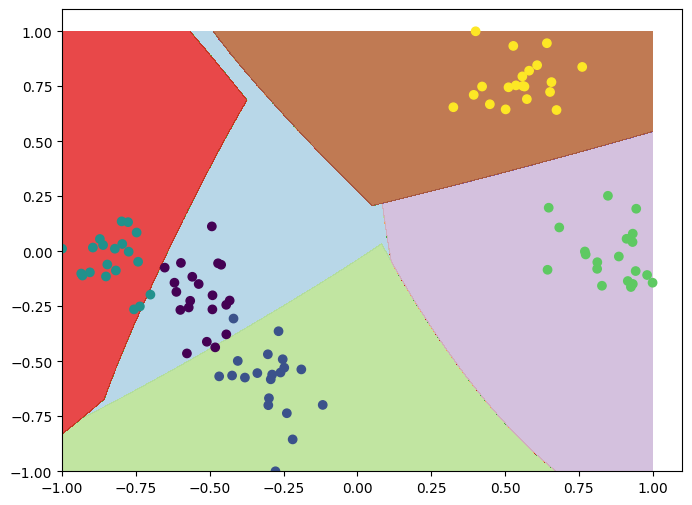

SVM com Kernel: POLY


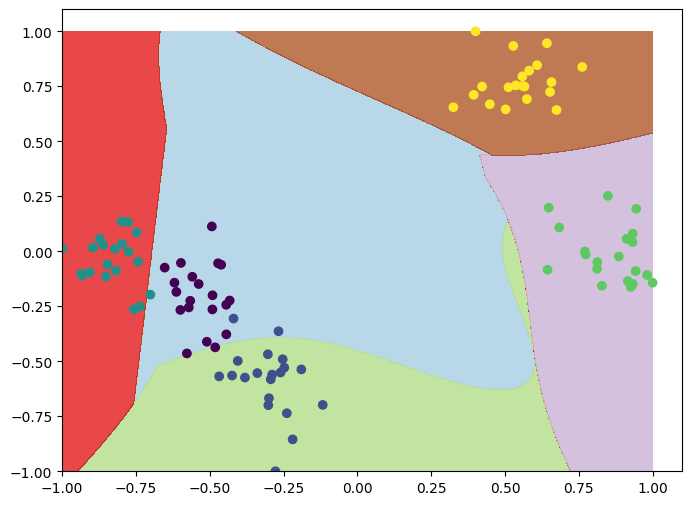

SVM com Kernel: SIGMOID


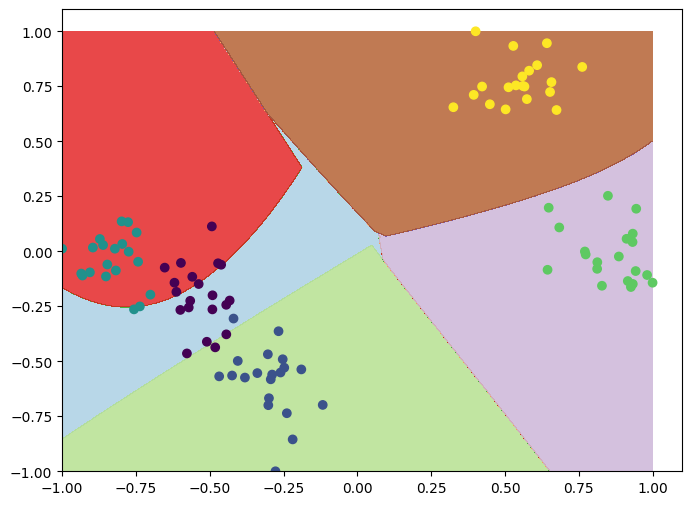

In [8]:
#Kernel RBF (Radial Basis Function)
# Costuma ser um dos mais eficientes para dados não-lineares.
print("SVM com Kernel: RBF")
svc_rbf = svm.SVC(kernel='rbf', C=C).fit(X, y)
plotPredictions(svc_rbf)

#Kernel Polinomial
# Tenta separar os dados usando curvas polinomiais.
print("SVM com Kernel: POLY")
svc_poly = svm.SVC(kernel='poly', C=C).fit(X, y)
plotPredictions(svc_poly)

#Kernel Sigmoid
# Usa funções sigmoides (semelhante a redes neurais antigas).
print("SVM com Kernel: SIGMOID")
svc_sigmoid = svm.SVC(kernel='sigmoid', C=C).fit(X, y)
plotPredictions(svc_sigmoid)